Number of events: 2325
Observation time: 3646.605824641204 days

Fitted parameters:
------------------
mu    = 0.29616
alpha = 0.90778
beta  = 1.69452

Optimization success: True


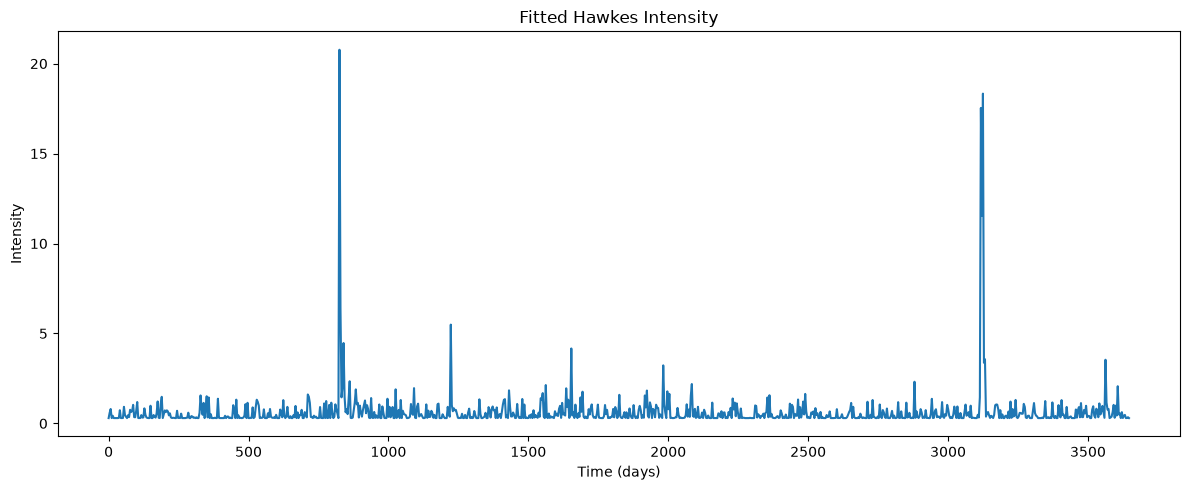


Branching ratio = 0.5357

Conclusion:

The Hawkes process models earthquake clustering through
self-excitation.

mu:
    background earthquake rate

alpha:
    strength of earthquake triggering

beta:
    decay speed of aftershock influence

alpha/beta:
    expected number of direct triggered events per earthquake



In [1]:
# ==============================================================
# Notebook 3: Hawkes Process Model
#
# Goal:
# - Implement a Hawkes self-exciting process
# - Fit parameters using maximum likelihood
#
# Model:
#
# lambda(t) = mu + sum(alpha * exp(-beta*(t-ti)))
#
# Parameters:
#
# mu    : background earthquake rate
# alpha : earthquake triggering strength
# beta  : decay speed of aftershock effect
#
# ==============================================================


# --------------------------------------------------------------
# 1. Imports
# --------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize

from src.hawkes import (
    hawkes_log_likelihood,
    intensity
)


# --------------------------------------------------------------
# 2. Load earthquake data
# --------------------------------------------------------------

df = pd.read_csv(
    "../data/earthquakes_greece_2016_2026.csv"
)

df["time"] = pd.to_datetime(df["time"])

df = (
    df
    .sort_values("time")
    .reset_index(drop=True)
)


# --------------------------------------------------------------
# 3. Convert event times to days
# --------------------------------------------------------------

t0 = df["time"].iloc[0]

times = (
    df["time"] - t0
).dt.total_seconds() / (24 * 3600)

times = times.values

T = times[-1]


print("Number of events:", len(times))
print("Observation time:", T, "days")


# --------------------------------------------------------------
# 4. Define objective function
# --------------------------------------------------------------
# scipy minimizes, therefore we minimize:
#
# negative log-likelihood
#

def objective(params):

    return -hawkes_log_likelihood(
        params,
        times
    )


# --------------------------------------------------------------
# 5. Fit Hawkes parameters
# --------------------------------------------------------------

initial_guess = [
    0.1,   # mu
    0.5,   # alpha
    1.0    # beta
]


result = minimize(
    objective,
    initial_guess,
    method="Nelder-Mead"
)


mu_hat, alpha_hat, beta_hat = result.x


print("\nFitted parameters:")
print("------------------")
print(f"mu    = {mu_hat:.5f}")
print(f"alpha = {alpha_hat:.5f}")
print(f"beta  = {beta_hat:.5f}")

print("\nOptimization success:", result.success)


# --------------------------------------------------------------
# 6. Save parameters
# --------------------------------------------------------------
# Notebook 4 can load these later

np.save(
    "../data/hawkes_params.npy",
    np.array(
        [
            mu_hat,
            alpha_hat,
            beta_hat
        ]
    )
)


# --------------------------------------------------------------
# 7. Plot fitted intensity
# --------------------------------------------------------------

grid = np.linspace(
    0,
    T,
    1000
)

lambda_values = []


for t in grid:

    history = times[times < t]

    lambda_values.append(
        intensity(
            t,
            history,
            mu_hat,
            alpha_hat,
            beta_hat
        )
    )


plt.figure(figsize=(12,5))

plt.plot(
    grid,
    lambda_values
)

plt.title("Fitted Hawkes Intensity")
plt.xlabel("Time (days)")
plt.ylabel("Intensity")

plt.tight_layout()
plt.show()


# --------------------------------------------------------------
# 8. Branching ratio
# --------------------------------------------------------------

branching_ratio = alpha_hat / beta_hat

print(
    f"\nBranching ratio = {branching_ratio:.4f}"
)


# --------------------------------------------------------------
# Conclusion
# --------------------------------------------------------------

print("""
Conclusion:

The Hawkes process models earthquake clustering through
self-excitation.

mu:
    background earthquake rate

alpha:
    strength of earthquake triggering

beta:
    decay speed of aftershock influence

alpha/beta:
    expected number of direct triggered events per earthquake
""")

In [2]:
# Save fitted Hawkes parameters

np.save(
    "../data/hawkes_params.npy",
    np.array([mu_hat, alpha_hat, beta_hat])
)